In [1]:
import pandas as pd

In [2]:
# url = "https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength"
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
df = pd.read_excel(url)
df.shape

(1030, 9)

In [4]:
col_rename = {'Cement (component 1)(kg in a m^3 mixture)':'cement',
'Blast Furnace Slag (component 2)(kg in a m^3 mixture)':'blast_furnace',
'Fly Ash (component 3)(kg in a m^3 mixture)':'fly_ash',
'Water  (component 4)(kg in a m^3 mixture)':'water',
'Superplasticizer (component 5)(kg in a m^3 mixture)':'superplasticizer',
'Coarse Aggregate  (component 6)(kg in a m^3 mixture)':'coarse_aggregate',
'Fine Aggregate (component 7)(kg in a m^3 mixture)':'fine_aggregate',
'Age (day)':'age',
'Concrete compressive strength(MPa, megapascals) ':'strength'}

df.rename(columns=col_rename,inplace=True)

In [5]:
df.head()

,cement,blast_furnace,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [6]:
X = df.drop('strength',axis=1)
y = df['strength']

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42)


In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
## build NN

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [14]:
model = Sequential()
model.add(Dense(16, input_dim = X_train.shape[1], activation = 'relu'))
model.add(Dense(8, activation = 'relu'))
model.add(Dense(1, activation = 'linear')) ## regression (for binary classification - sigmoid, multiclass classification - softmax)
model.compile(optimizer = 'adam',loss='mse',metrics=['mae'])

history = model.fit(X_train, y_train, epochs=50, batch_size = 16, validation_split = 0.2, verbose = 1)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1519.9395 - mae: 35.1884 - val_loss: 1473.7869 - val_mae: 35.1981
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1453.6221 - mae: 34.2397 - val_loss: 1392.4838 - val_mae: 34.0506
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1370.0117 - mae: 32.8264 - val_loss: 1267.8010 - val_mae: 32.2162
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1201.0299 - mae: 30.3697 - val_loss: 1093.7958 - val_mae: 29.4962
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1034.5286 - mae: 27.8058 - val_loss: 882.4810 - val_mae: 25.9094
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 835.2070 - mae: 24.0830 - val_loss: 655.5245 - val_mae: 21.5514
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 605.6688 - mae: 19.6787 - val_loss: 460.2463 - val_mae: 17.3217
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 413.9092 - mae: 15.8997 - val_loss: 318.1414 - val_mae: 14.0122
Epoch 9/50
42/42 ━━━━━━━━

In [15]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 869 (3.40 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 580 (2.27 KB)

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [18]:

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)

print(f"Test MSE: {mse}")
print(f"Test R2 Score: {r2}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Test MSE: 105.8733362178279
Test R2 Score: 0.5891303587662367


In [19]:
import matplotlib.pyplot as plt

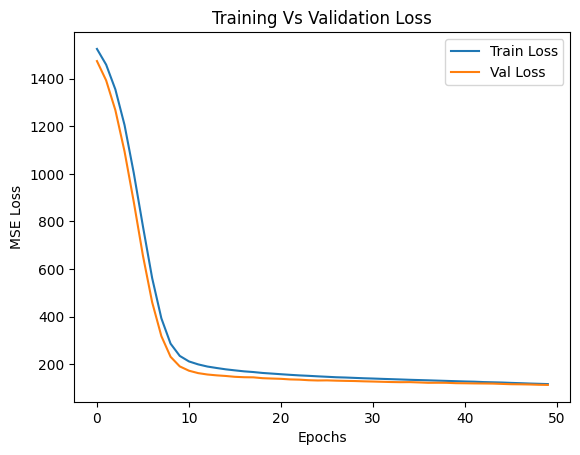

In [20]:
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()

plt.title("Training Vs Validation Loss")
plt.show()